In [110]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("chinook.db")

## Q1. Write a query to list the top 10 genres with the highest number of tracks. (Show in bar plot)

In [23]:
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(tables)


[('album',), ('artist',), ('customer',), ('employee',), ('genre',), ('invoice',), ('invoice_line',), ('media_type',), ('playlist',), ('playlist_track',), ('track',), ('wishlist_track',), ('wishlist',)]


In [25]:

cursor = conn.cursor()

cursor.execute("PRAGMA table_info(track);")
columns = cursor.fetchall()
for col in columns:
    print(col)



(0, 'track_id', 'INTEGER', 1, None, 1)
(1, 'name', 'NVARCHAR(200)', 1, None, 0)
(2, 'album_id', 'INTEGER', 0, None, 0)
(3, 'media_type_id', 'INTEGER', 1, None, 0)
(4, 'genre_id', 'INTEGER', 0, None, 0)
(5, 'composer', 'NVARCHAR(220)', 0, None, 0)
(6, 'milliseconds', 'INTEGER', 1, None, 0)
(7, 'bytes', 'INTEGER', 0, None, 0)
(8, 'unit_price', 'NUMERIC(10,2)', 1, None, 0)


In [27]:
query = """
SELECT g.name AS Genre,
       COUNT(t.track_id) AS TrackCount
FROM genre g
JOIN track t ON g.genre_id = t.genre_id
GROUP BY g.name
ORDER BY TrackCount DESC
LIMIT 10;
"""

df = pd.read_sql_query(query, conn)
conn.close()

print(df)


                Genre  TrackCount
0                Rock        1297
1               Latin         579
2               Metal         374
3  Alternative & Punk         332
4                Jazz         130
5            TV Shows          93
6               Blues          81
7           Classical          74
8               Drama          64
9            R&B/Soul          61


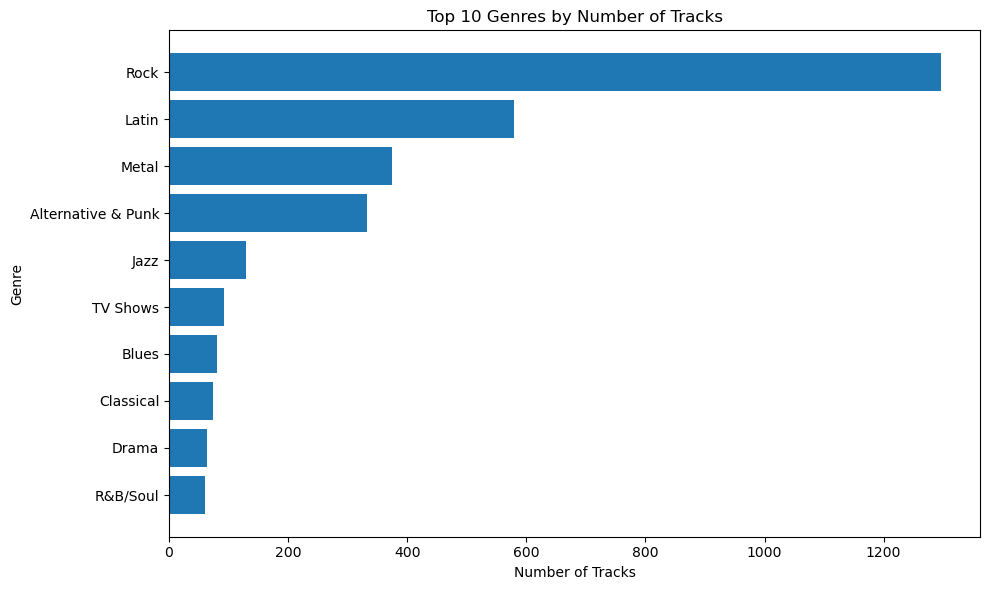

In [29]:
# Plot
plt.figure(figsize=(10, 6))
plt.barh(df['Genre'], df['TrackCount'])  # horizontal bar for readability
plt.xlabel("Number of Tracks")
plt.ylabel("Genre")
plt.title("Top 10 Genres by Number of Tracks")
plt.gca().invert_yaxis()  # highest at top
plt.tight_layout()
plt.show()

## Q2. Write a query to list the top 10 albums that contain the most tracks.

In [38]:

query = """
SELECT a.title AS Album,
       COUNT(t.track_id) AS TrackCount
FROM album a
JOIN track t ON a.album_id = t.album_id
GROUP BY a.title
ORDER BY TrackCount DESC
LIMIT 10;
"""

df = pd.read_sql_query(query, conn)
conn.close()

# Show DataFrame
print(df)


                                               Album  TrackCount
0                                      Greatest Hits          57
1                                     Minha Historia          34
2                                          Unplugged          30
3                                     Lost, Season 3          26
4                               The Office, Season 3          25
5                                     Lost, Season 1          25
6         My Way: The Best Of Frank Sinatra [Disc 1]          24
7                                     Lost, Season 2          24
8           Battlestar Galactica (Classic), Season 1          24
9  Instant Karma: The Amnesty International Campa...          23


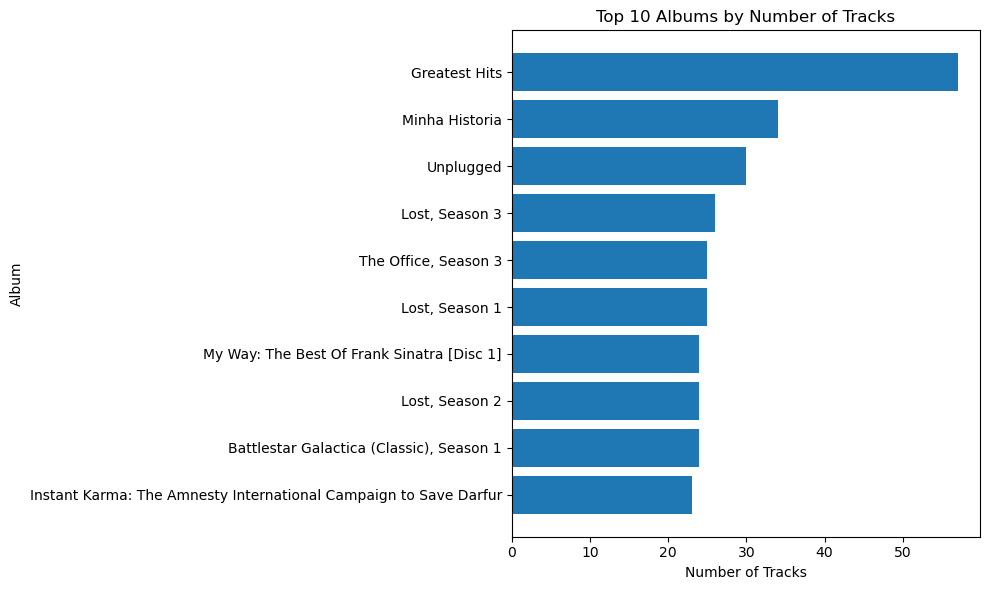

In [40]:
# Plot
plt.figure(figsize=(10, 6))
plt.barh(df['Album'], df['TrackCount'])
plt.xlabel("Number of Tracks")
plt.ylabel("Album")
plt.title("Top 10 Albums by Number of Tracks")
plt.gca().invert_yaxis()  # Highest at top
plt.tight_layout()
plt.show()

## Q3. Write a query to find the top 10 customers who spent the most money.

In [47]:

query = """
SELECT c.first_name || ' ' || c.last_name AS Customer,
       SUM(il.unit_price * il.quantity) AS TotalSpent
FROM customer c
JOIN invoice i ON c.customer_id = i.customer_id
JOIN invoice_line il ON i.invoice_id = il.invoice_id
GROUP BY Customer
ORDER BY TotalSpent DESC
LIMIT 10;
"""

df = pd.read_sql_query(query, conn)
conn.close()

# Display data
print(df)


                Customer  TotalSpent
0  František Wichterlová      144.54
1            Helena Holý      128.70
2          Hugh O'Reilly      114.84
3           Manoj Pareek      111.87
4         Luís Gonçalves      108.90
5         Fernanda Ramos      106.92
6         João Fernandes      102.96
7           Wyatt Girard       99.99
8      François Tremblay       99.99
9            Phil Hughes       98.01


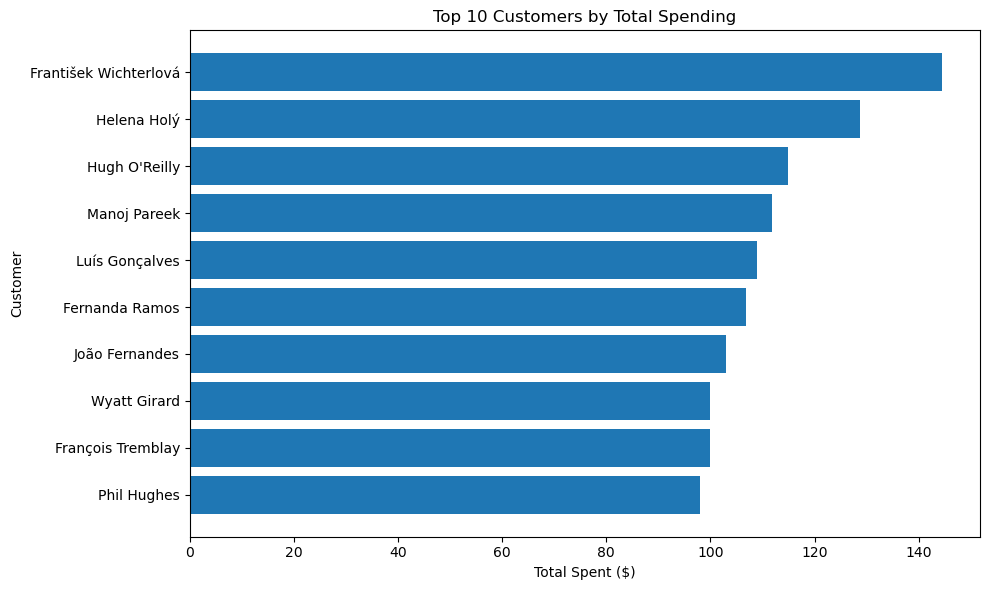

In [49]:
# Plot
plt.figure(figsize=(10, 6))
plt.barh(df['Customer'], df['TotalSpent'])
plt.xlabel("Total Spent ($)")
plt.ylabel("Customer")
plt.title("Top 10 Customers by Total Spending")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Q4. Write a query to find the top 5 artists who generated the highest revenue from track sales.

In [56]:
query = """
SELECT ar.name AS Artist,
       SUM(il.unit_price * il.quantity) AS TotalRevenue
FROM artist ar
JOIN album al ON ar.artist_id = al.artist_id
JOIN track t ON al.album_id = t.album_id
JOIN invoice_line il ON t.track_id = il.track_id
GROUP BY ar.name
ORDER BY TotalRevenue DESC
LIMIT 5;
"""

df = pd.read_sql_query(query, conn)
conn.close()

# Show results
print(df)


                  Artist  TotalRevenue
0                  Queen        190.08
1           Jimi Hendrix        185.13
2  Red Hot Chili Peppers        128.70
3                Nirvana        128.70
4              Pearl Jam        127.71


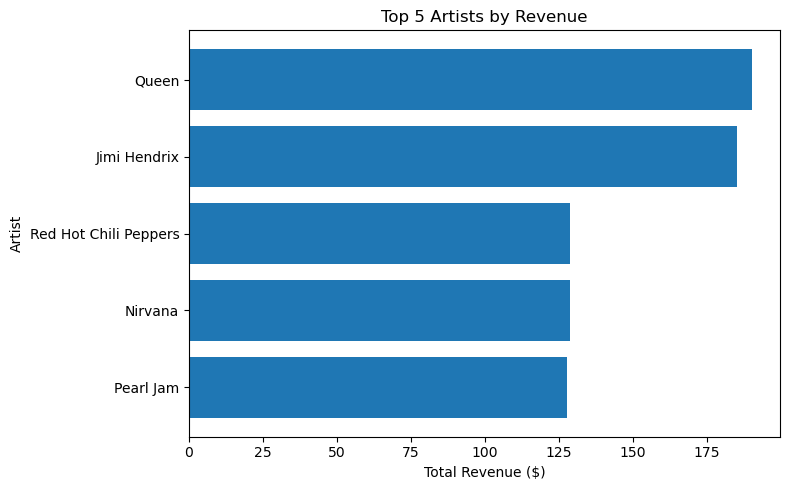

In [58]:
# Plot
plt.figure(figsize=(8, 5))
plt.barh(df['Artist'], df['TotalRevenue'])
plt.xlabel("Total Revenue ($)")
plt.ylabel("Artist")
plt.title("Top 5 Artists by Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Q5. Countries by Average Revenue per Invoice

In [64]:
query = """
SELECT c.country AS Country,
       ROUND(AVG(inv.total), 2) AS AvgRevenuePerInvoice
FROM customer c
JOIN invoice inv ON c.customer_id = inv.customer_id
GROUP BY c.country
ORDER BY AvgRevenuePerInvoice DESC;
"""

df = pd.read_sql_query(query, conn)
conn.close()

# Show results
print(df)


           Country  AvgRevenuePerInvoice
0   Czech Republic                  9.11
1            Spain                  8.91
2          Ireland                  8.83
3   United Kingdom                  8.77
4            India                  8.72
5          Belgium                  8.63
6          Germany                  8.16
7        Australia                  8.12
8           Norway                  8.03
9              USA                  7.94
10       Argentina                  7.92
11         Hungary                  7.82
12          France                  7.78
13         Austria                  7.70
14          Poland                  7.62
15          Sweden                  7.52
16           Chile                  7.46
17         Finland                  7.20
18          Canada                  7.05
19          Brazil                  7.01
20     Netherlands                  6.53
21        Portugal                  6.38
22           Italy                  5.61
23         Denma

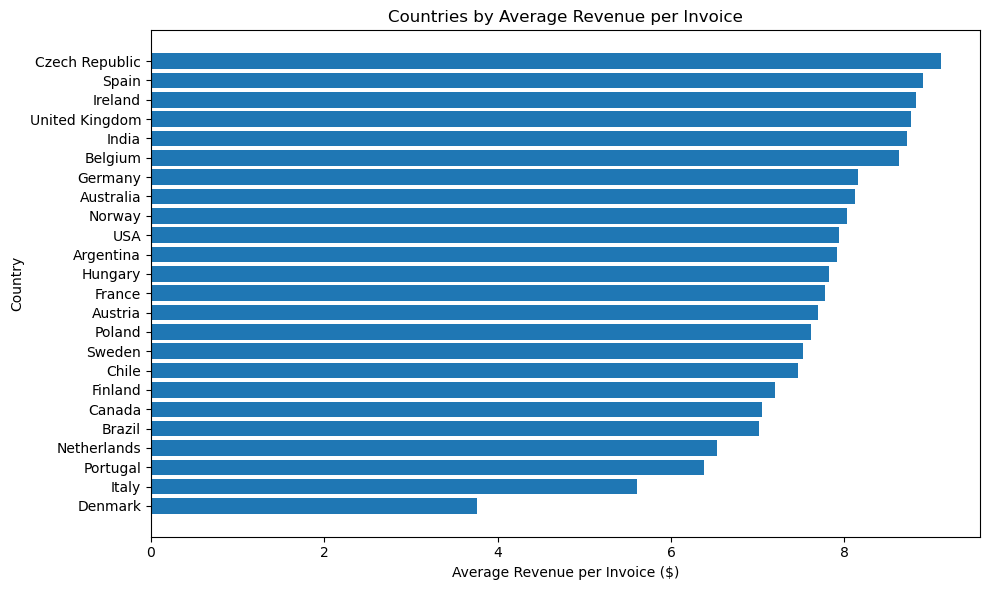

In [66]:
# Plot
plt.figure(figsize=(10, 6))
plt.barh(df['Country'], df['AvgRevenuePerInvoice'])
plt.xlabel("Average Revenue per Invoice ($)")
plt.ylabel("Country")
plt.title("Countries by Average Revenue per Invoice")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Q6. Write a query to find the media type with number of tracks.


In [70]:
query = """
SELECT m.name AS MediaType,
       COUNT(t.track_id) AS TrackCount
FROM media_type m
JOIN track t ON m.media_type_id = t.media_type_id
GROUP BY m.name
ORDER BY TrackCount DESC;
"""

df = pd.read_sql_query(query, conn)
conn.close()

# Show results
print(df)


                     MediaType  TrackCount
0              MPEG audio file        3034
1     Protected AAC audio file         237
2  Protected MPEG-4 video file         214
3               AAC audio file          11
4     Purchased AAC audio file           7


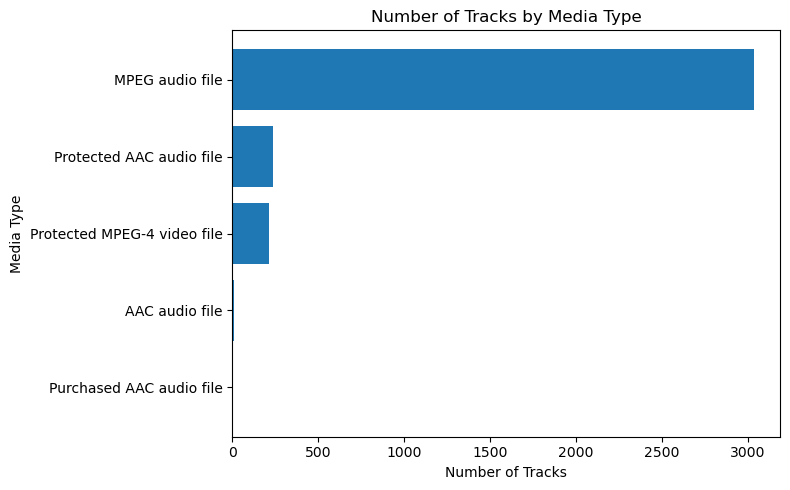

In [72]:
# Plot
plt.figure(figsize=(8, 5))
plt.barh(df['MediaType'], df['TrackCount'])
plt.xlabel("Number of Tracks")
plt.ylabel("Media Type")
plt.title("Number of Tracks by Media Type")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Q7. Which artists have released tracks in more than one genre?

In [78]:
query = """
SELECT ar.name AS Artist,
       COUNT(DISTINCT g.genre_id) AS GenreCount
FROM artist ar
JOIN album al ON ar.artist_id = al.artist_id
JOIN track t ON al.album_id = t.album_id
JOIN genre g ON t.genre_id = g.genre_id
GROUP BY ar.name
HAVING COUNT(DISTINCT g.genre_id) > 1
ORDER BY GenreCount DESC, ar.name;
"""

df = pd.read_sql_query(query, conn)
conn.close()

# Show results
print(df)


                   Artist  GenreCount
0             Iron Maiden           4
1              Audioslave           3
2    Battlestar Galactica           3
3            Gilberto Gil           3
4              Jamiroquai           3
5           Lenny Kravitz           3
6         Various Artists           3
7           Amy Winehouse           2
8    Antônio Carlos Jobim           2
9            Eric Clapton           2
10          Faith No More           2
11           Foo Fighters           2
12          Guns N' Roses           2
13                 Heroes           2
14                   Lost           2
15          Ozzy Osbourne           2
16              Pearl Jam           2
17                 R.E.M.           2
18  Red Hot Chili Peppers           2
19             The Office           2
20                     U2           2


## Q8. Write a query to list the top 10 longest tracks by duration.

In [84]:
query = """
SELECT t.name AS TrackName,
       t.milliseconds / 60000.0 AS DurationMinutes
FROM track t
ORDER BY t.milliseconds DESC
LIMIT 10;
"""

df = pd.read_sql_query(query, conn)
conn.close()

# Show results
print(df)


                     TrackName  DurationMinutes
0       Occupation / Precipice        88.115883
1      Through a Looking Glass        84.813967
2  Greetings from Earth, Pt. 1        49.338217
3      The Man With Nine Lives        49.283300
4  Battlestar Galactica, Pt. 2        49.268017
5  Battlestar Galactica, Pt. 1        49.211700
6    Murder On the Rising Star        48.931567
7  Battlestar Galactica, Pt. 3        48.796700
8            Take the Celestra        48.794617
9                Fire In Space        48.776550


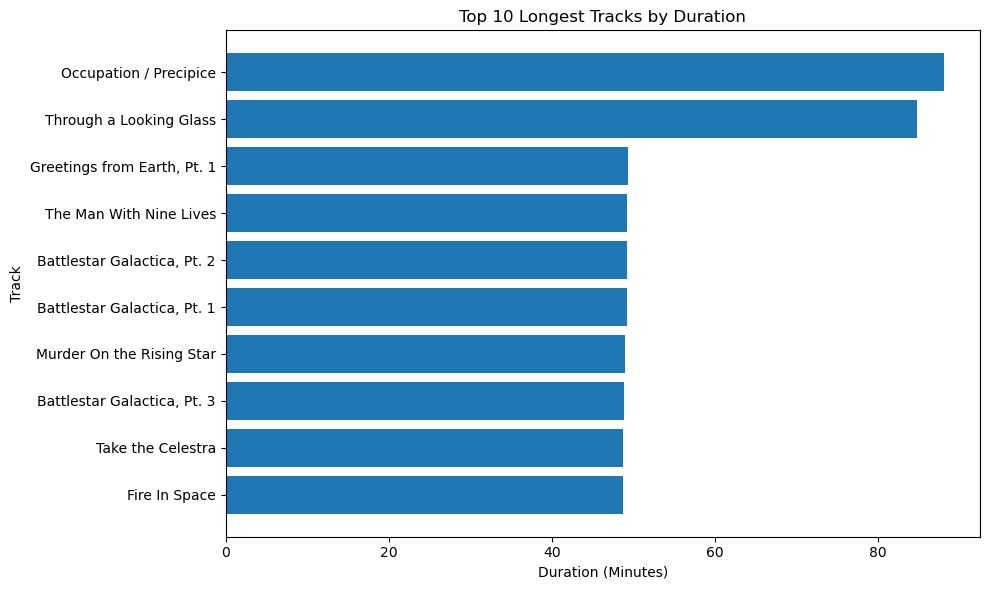

In [86]:
# Plot
plt.figure(figsize=(10, 6))
plt.barh(df['TrackName'], df['DurationMinutes'])
plt.xlabel("Duration (Minutes)")
plt.ylabel("Track")
plt.title("Top 10 Longest Tracks by Duration")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Q9. Top 5 Revenue Share percentage by Artist (Pie Chart)

In [92]:
query = """
SELECT ar.name AS Artist,
       SUM(il.unit_price * il.quantity) AS TotalRevenue
FROM artist ar
JOIN album al ON ar.artist_id = al.artist_id
JOIN track t ON al.album_id = t.album_id
JOIN invoice_line il ON t.track_id = il.track_id
GROUP BY ar.name
ORDER BY TotalRevenue DESC
LIMIT 5;
"""

df = pd.read_sql_query(query, conn)
conn.close()

# Calculate percentage share
total_revenue = df['TotalRevenue'].sum()
df['RevenueShare'] = (df['TotalRevenue'] / total_revenue) * 100

# Show results
print(df)

                  Artist  TotalRevenue  RevenueShare
0                  Queen        190.08     25.000000
1           Jimi Hendrix        185.13     24.348958
2  Red Hot Chili Peppers        128.70     16.927083
3                Nirvana        128.70     16.927083
4              Pearl Jam        127.71     16.796875


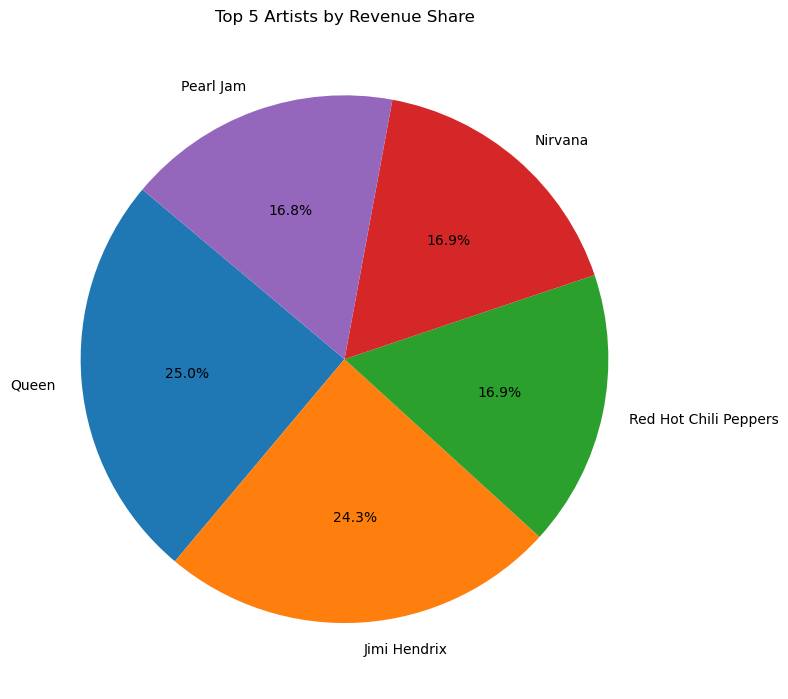

In [94]:
# Plot Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(df['TotalRevenue'], labels=df['Artist'], autopct='%1.1f%%', startangle=140)
plt.title("Top 5 Artists by Revenue Share")
plt.tight_layout()
plt.show()

## Q10. Revenue by Genre (Rock, Latin, Metal) in Each Country (Stacked Column Chart)

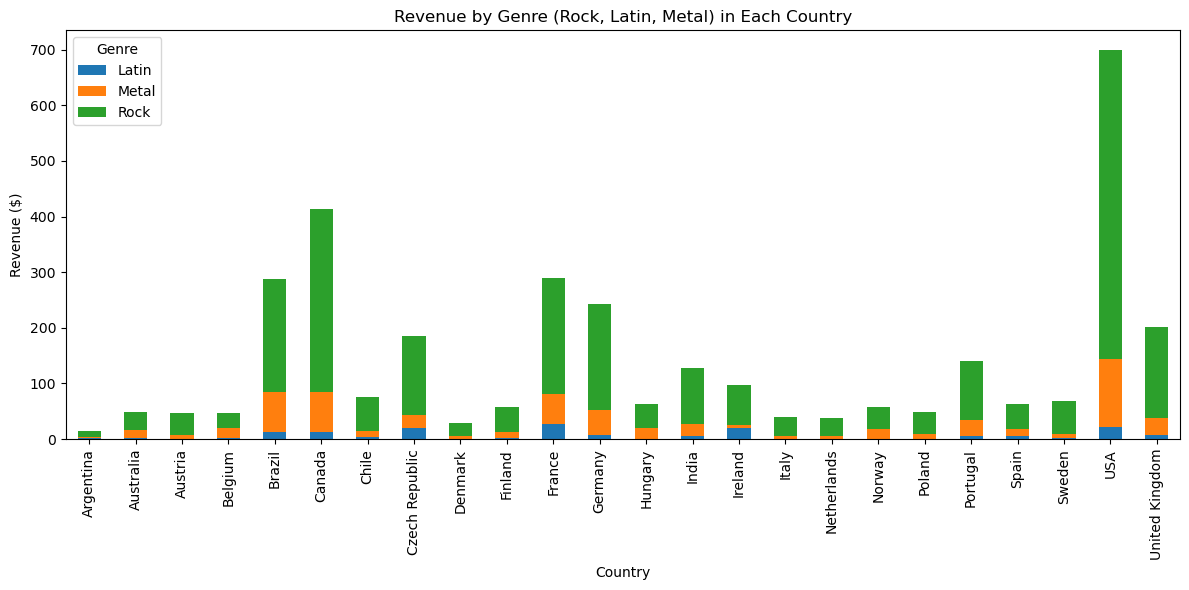

In [112]:
query = """
SELECT c.country AS Country,
       g.name AS Genre,
       SUM(il.unit_price * il.quantity) AS Revenue
FROM customer c
JOIN invoice i ON c.customer_id = i.customer_id
JOIN invoice_line il ON i.invoice_id = il.invoice_id
JOIN track t ON il.track_id = t.track_id
JOIN genre g ON t.genre_id = g.genre_id
WHERE g.name IN ('Rock', 'Latin', 'Metal')
GROUP BY c.country, g.name
ORDER BY c.country, g.name;
"""

df = pd.read_sql_query(query, conn)
conn.close()

# Pivot for stacked bar chart
pivot_df = df.pivot(index='Country', columns='Genre', values='Revenue').fillna(0)

# Plot stacked bar chart
pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.ylabel("Revenue ($)")
plt.title("Revenue by Genre (Rock, Latin, Metal) in Each Country")
plt.legend(title="Genre")
plt.tight_layout()
plt.show()
